# Telecom Customer Churn Prediction

### Problem Statement
##### The telecom company is experiencing customer churn. It is difficult to identify which customers are likely to leave, resulting in revenue loss and increased customer acquisition costs.


### Business Objective
##### Help the telecom company identify customers at risk of churn so that retention strategies can be applied proactively.


### Project Goal
#### Develop a classification model that predicts whether a customer will churn or not.

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # plotting graphs
import seaborn as sns # plotting graphs

In [ ]:
sns.set_theme()

In [ ]:
df = pd.read_excel('Telco_customer_churn.xlsx')

## Dataset Overview

In [3]:
# Complete Dataset Overview
pd.set_option('display.max_columns', None)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [1]:
df.shape

NameError: name 'df' is not defined

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
# Converting 'Total Charges' column from object into numeric
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [6]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [7]:
# Checking correlation of numerical columns
df.corr(numeric_only = True)

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.001462,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.010313,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.009047,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.825880,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.651065,0.193356,0.133754,0.098693
Total Charges,NaN,-0.001462,-0.010313,0.009047,0.825880,0.651065,1.000000,-0.199484,-0.124312,0.341837
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.199484,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.124312,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,0.341837,-0.127463,-0.079782,1.000000


In [8]:
# Removing the columns which are either not important in predicting the output or cause leakage

df.drop(columns = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Longitude', 'Latitude', 'Churn Reason', 'CLTV', 'Churn Score', 'Churn Label'], inplace = True)

**The columns we've selected gives different type of information**
* Customer demographics (Gender, Senior Citizen, Partner, Dependents)
* Service usage (Phone Service, Internet Service, Streaming, Security, Online Backup, Device Protection, Streaming, etc..)
* Billing information (Monthly Charges, Total Charges, Payment Method)
* Customer relationship information (Tenure, Contract, Total Charges)
  

In [9]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [10]:
# Checking Missing Values
df.isnull().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64

In [11]:
# Checking Unique values in each column
df.nunique()

Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6530
Churn Value             2
dtype: int64

# Exploratory Data Analysis

## Univariate Analysis

### Numerical Columns Analysis

In [12]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0


In [13]:
(df['Churn Value'].value_counts()/ len(df) ) * 100
# 26% users have churned while 73% are remained.

Churn Value
0    73.463013
1    26.536987
Name: count, dtype: float64

Text(0.5, 0.98, 'Churn Value')

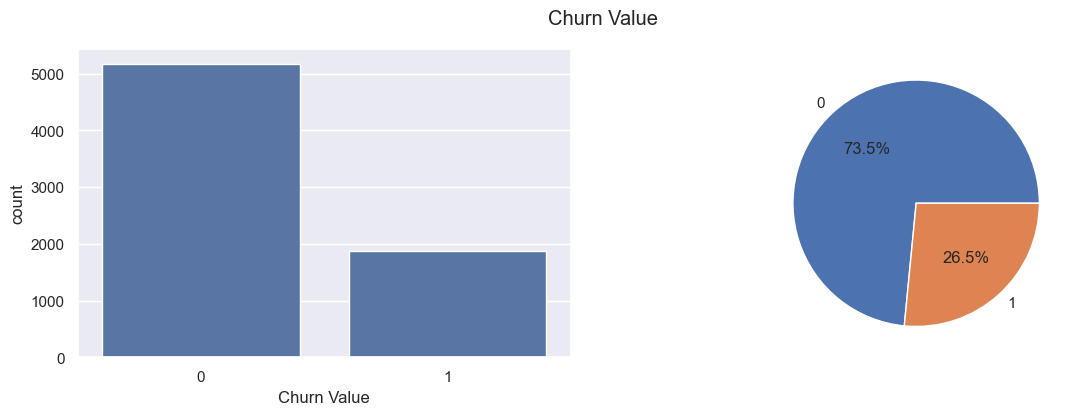

In [14]:
fig, ax = plt.subplots(1,2, figsize = (14,4))

sns.countplot(x = 'Churn Value', data = df, ax = ax[0])
ax[1].pie(df['Churn Value'].value_counts(), labels=df['Churn Value'].value_counts().index,autopct='%1.1f%%')

fig.suptitle('Churn Value')

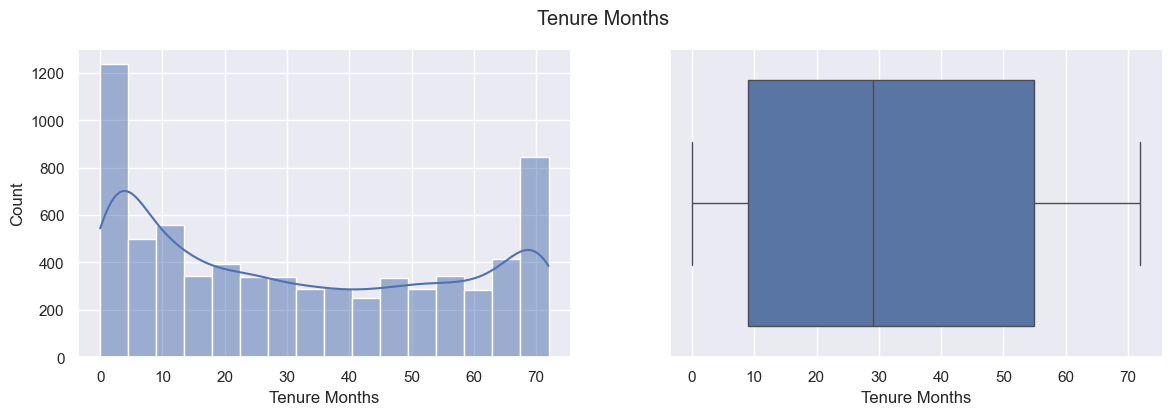

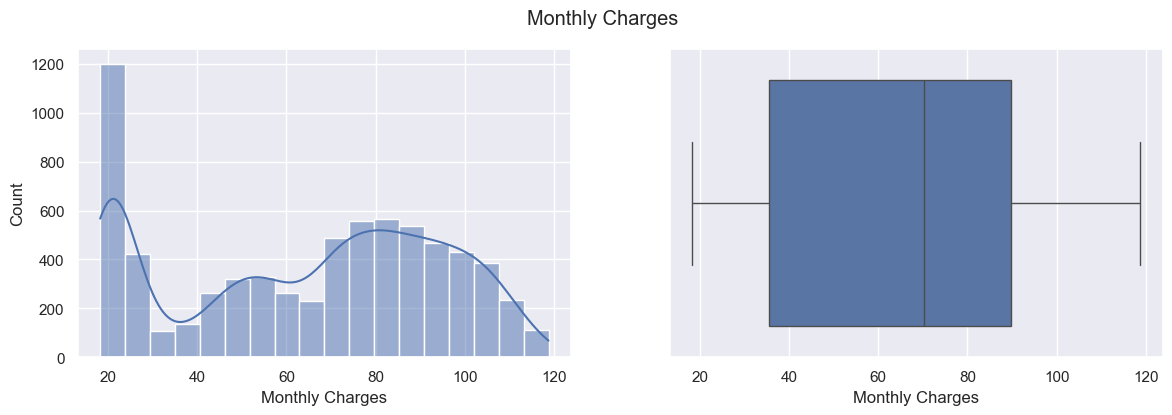

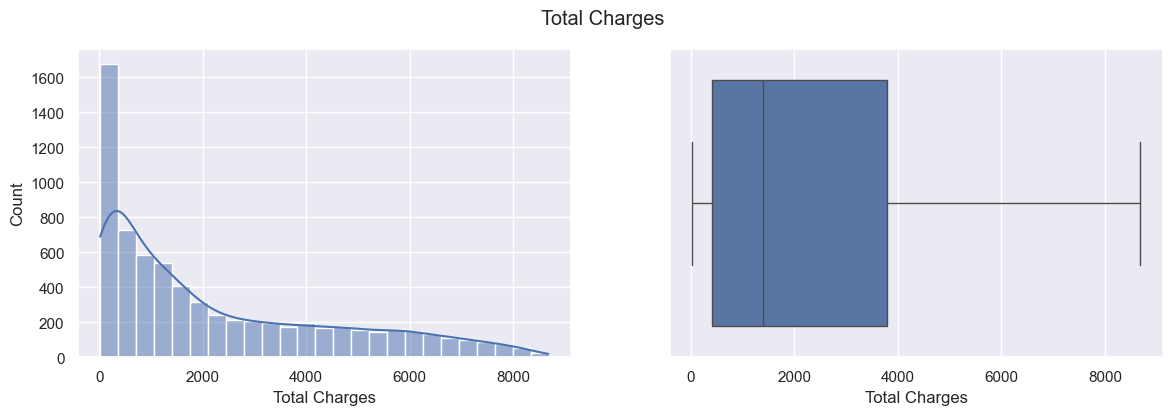

In [94]:
num_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

for col in num_cols:
    fig, ax = plt.subplots(1,2, figsize = (14,4))
    sns.histplot(data = df, x = col, kde = True, ax = ax[0])
    sns.boxplot(data = df, x = col, ax = ax[1])
    fig.suptitle(col)

Most customers have either been using the company's services for 1–10 months or for 65–72 months. This indicates that a large portion of customers in the dataset are either newly joined or long-term customers.

In [96]:
df['Tenure Months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Months, dtype: float64

In [17]:
df['Monthly Charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [19]:
df['Total Charges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: Total Charges, dtype: float64

Total Charges column is also giving the same information that most of the customers are either paying very low monthly or they are newly joined.

No extreme outliers were observed.

### Categorical Columns Analysis

In [22]:
cat_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

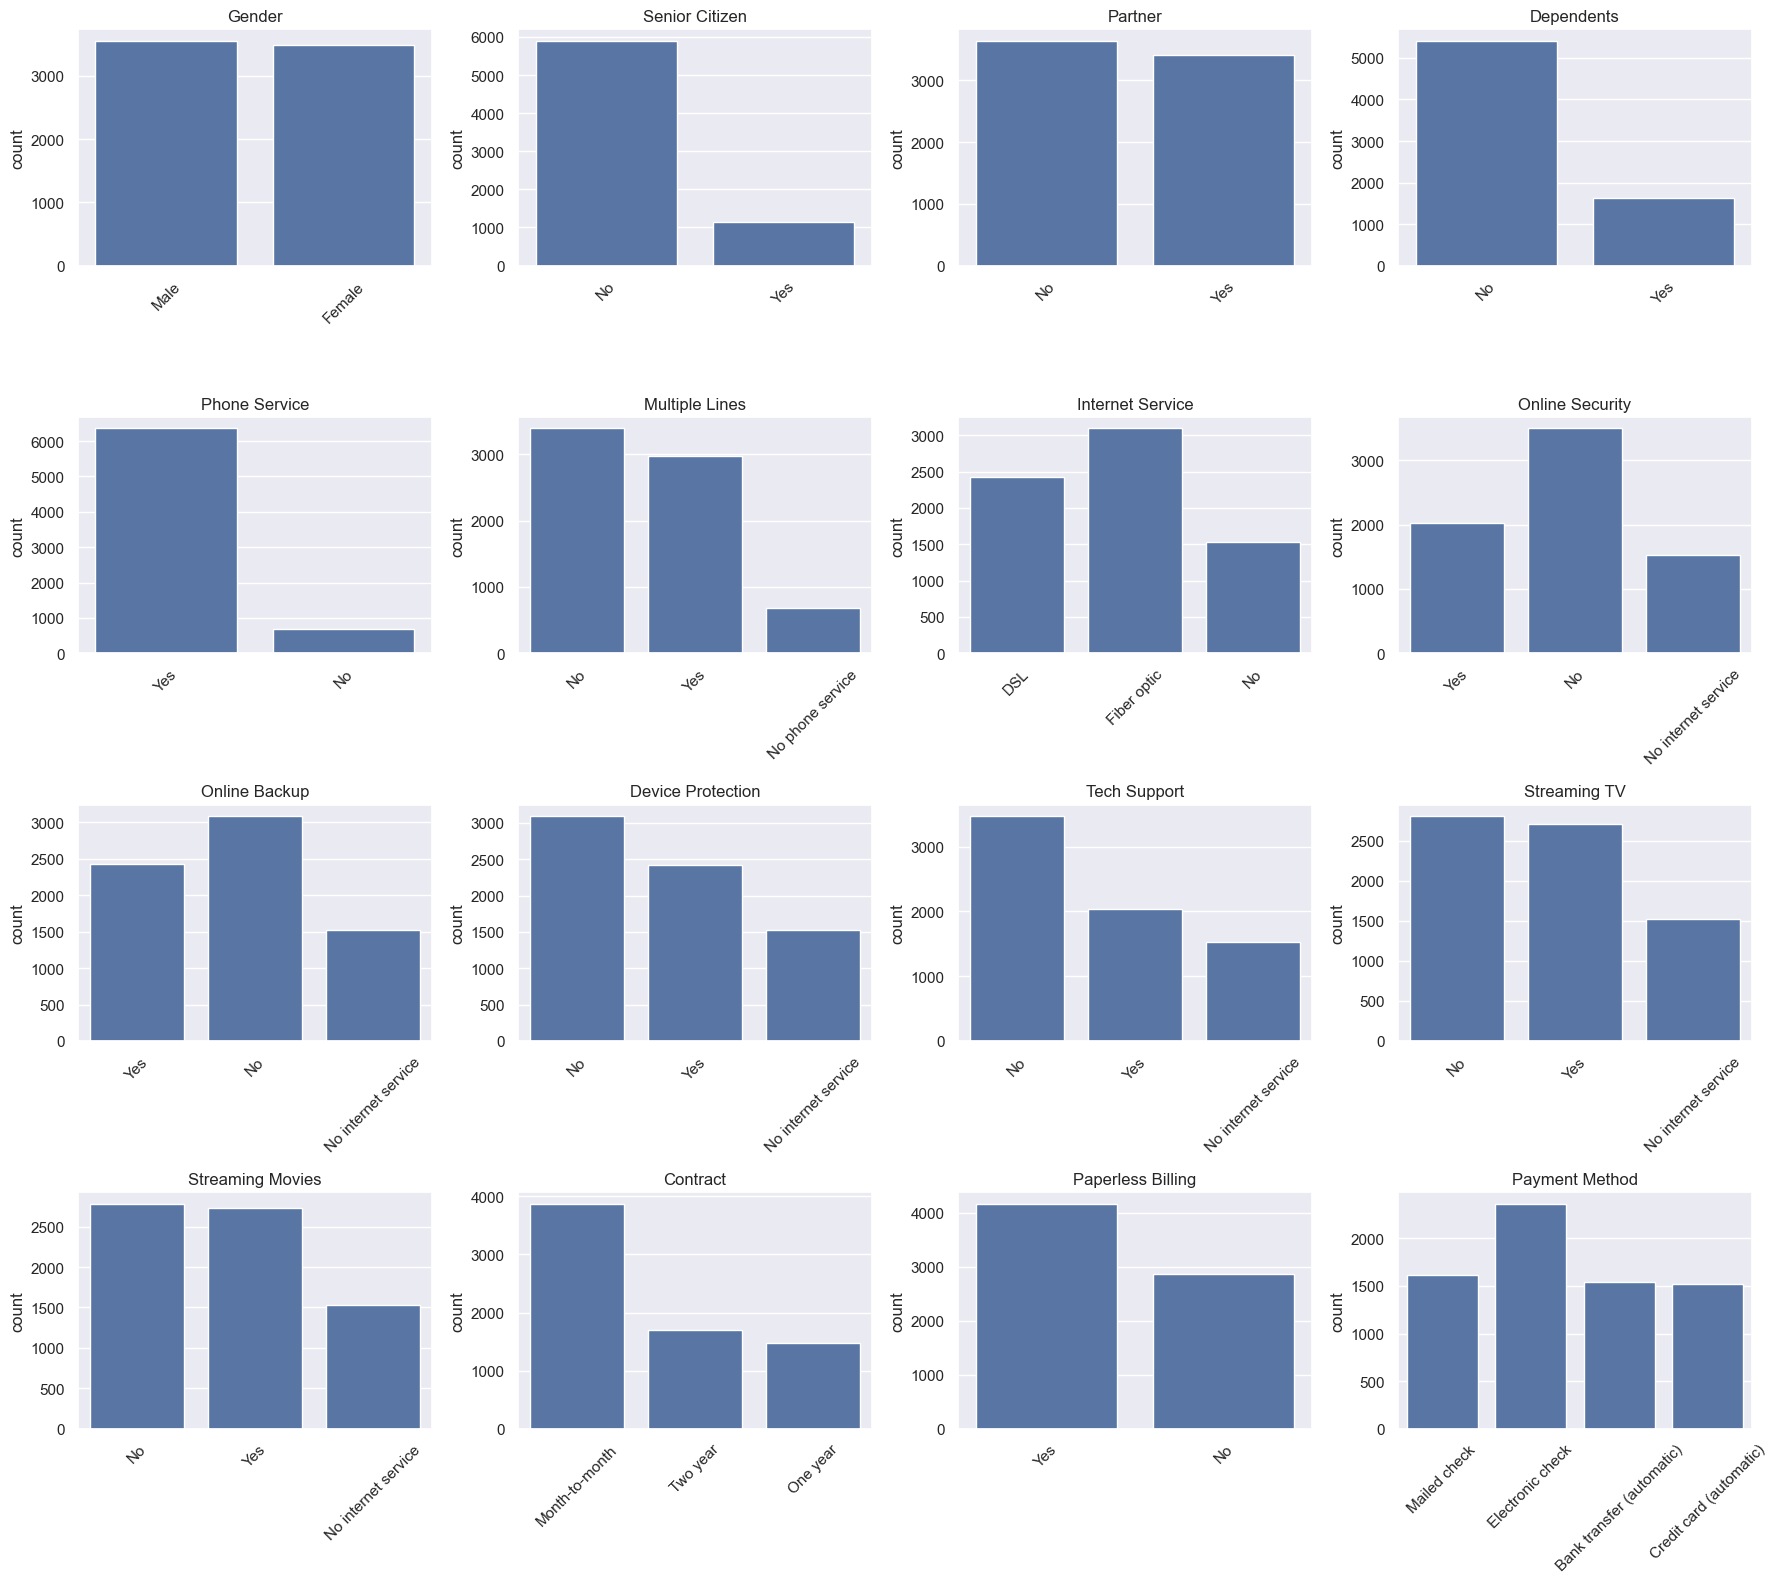

In [23]:
fig, ax = plt.subplots(4,4, figsize=(18, 16))

ax = ax.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(data=df, x=col, ax=ax[i])

    ax[i].set_title(col)
    ax[i].set_xlabel('')   # removes bottom label
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Key Insights from Categorical Features**
* Gender distribution is almost balanced, with nearly equal numbers of male and female customers.
* Most customers are not senior citizens, indicating the customer base is dominated by younger users.
* The majority of customers do not have dependents.
* Almost all customers have a phone service.
* Fiber optic is the most commonly used internet service, followed by DSL.
* More customers do not use Online Security, Online Backup, Device Protection, and Tech Support than those who do.
* The customer base is almost evenly split between users and non-users of Streaming TV and Streaming Movies.
* Month-to-Month contracts are the most common contract type, significantly more than one-year or two-year contracts.
* A majority of customers use Paperless Billing.
* Electronic Check is the most frequently used payment method.

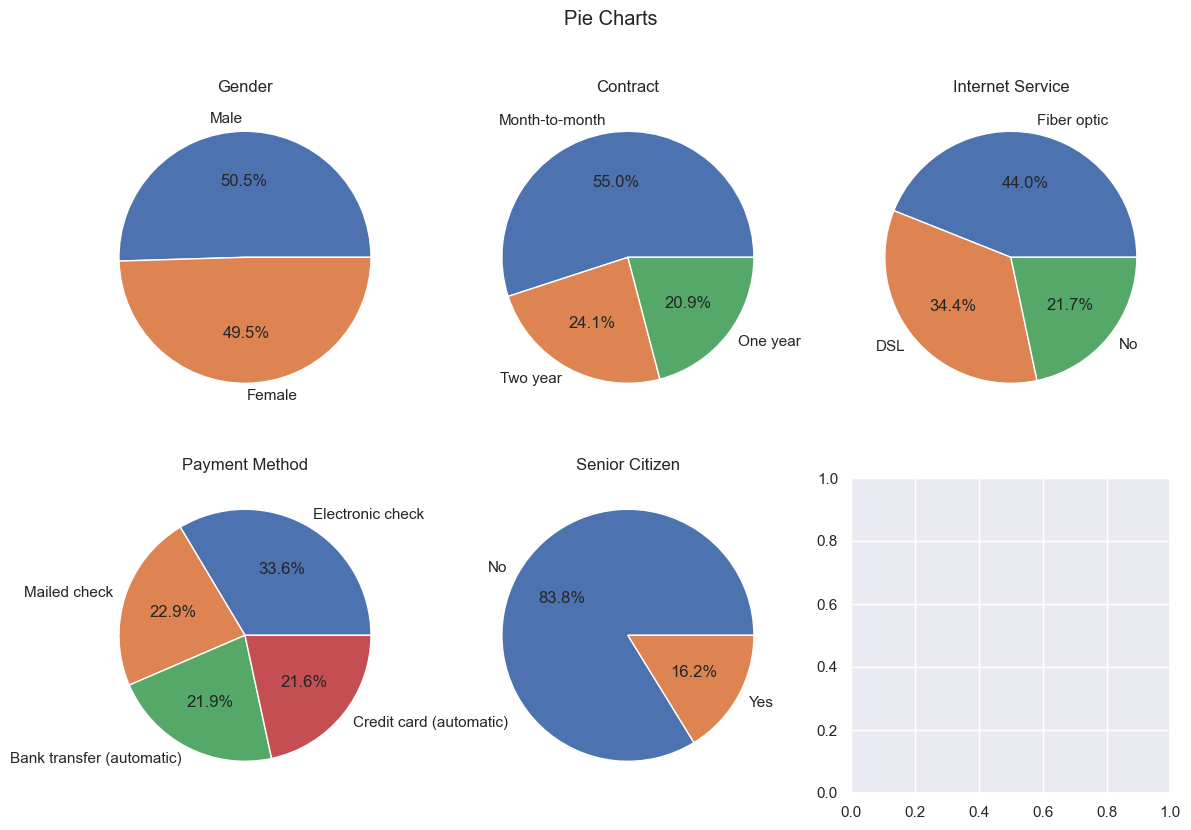

In [24]:
pie_cat_cols = ['Gender','Contract','Internet Service','Payment Method','Senior Citizen']

fig, ax = plt.subplots(2,3, figsize = (14, 9))
for col in pie_cat_cols:
    ax = ax.flatten()
    ax[pie_cat_cols.index(col)].pie(df[col].value_counts(), labels=df[col].value_counts().index,autopct='%1.1f%%')
    ax[pie_cat_cols.index(col)].set_title(col)
fig.suptitle("Pie Charts")
plt.show()

## Bivariate Analysis

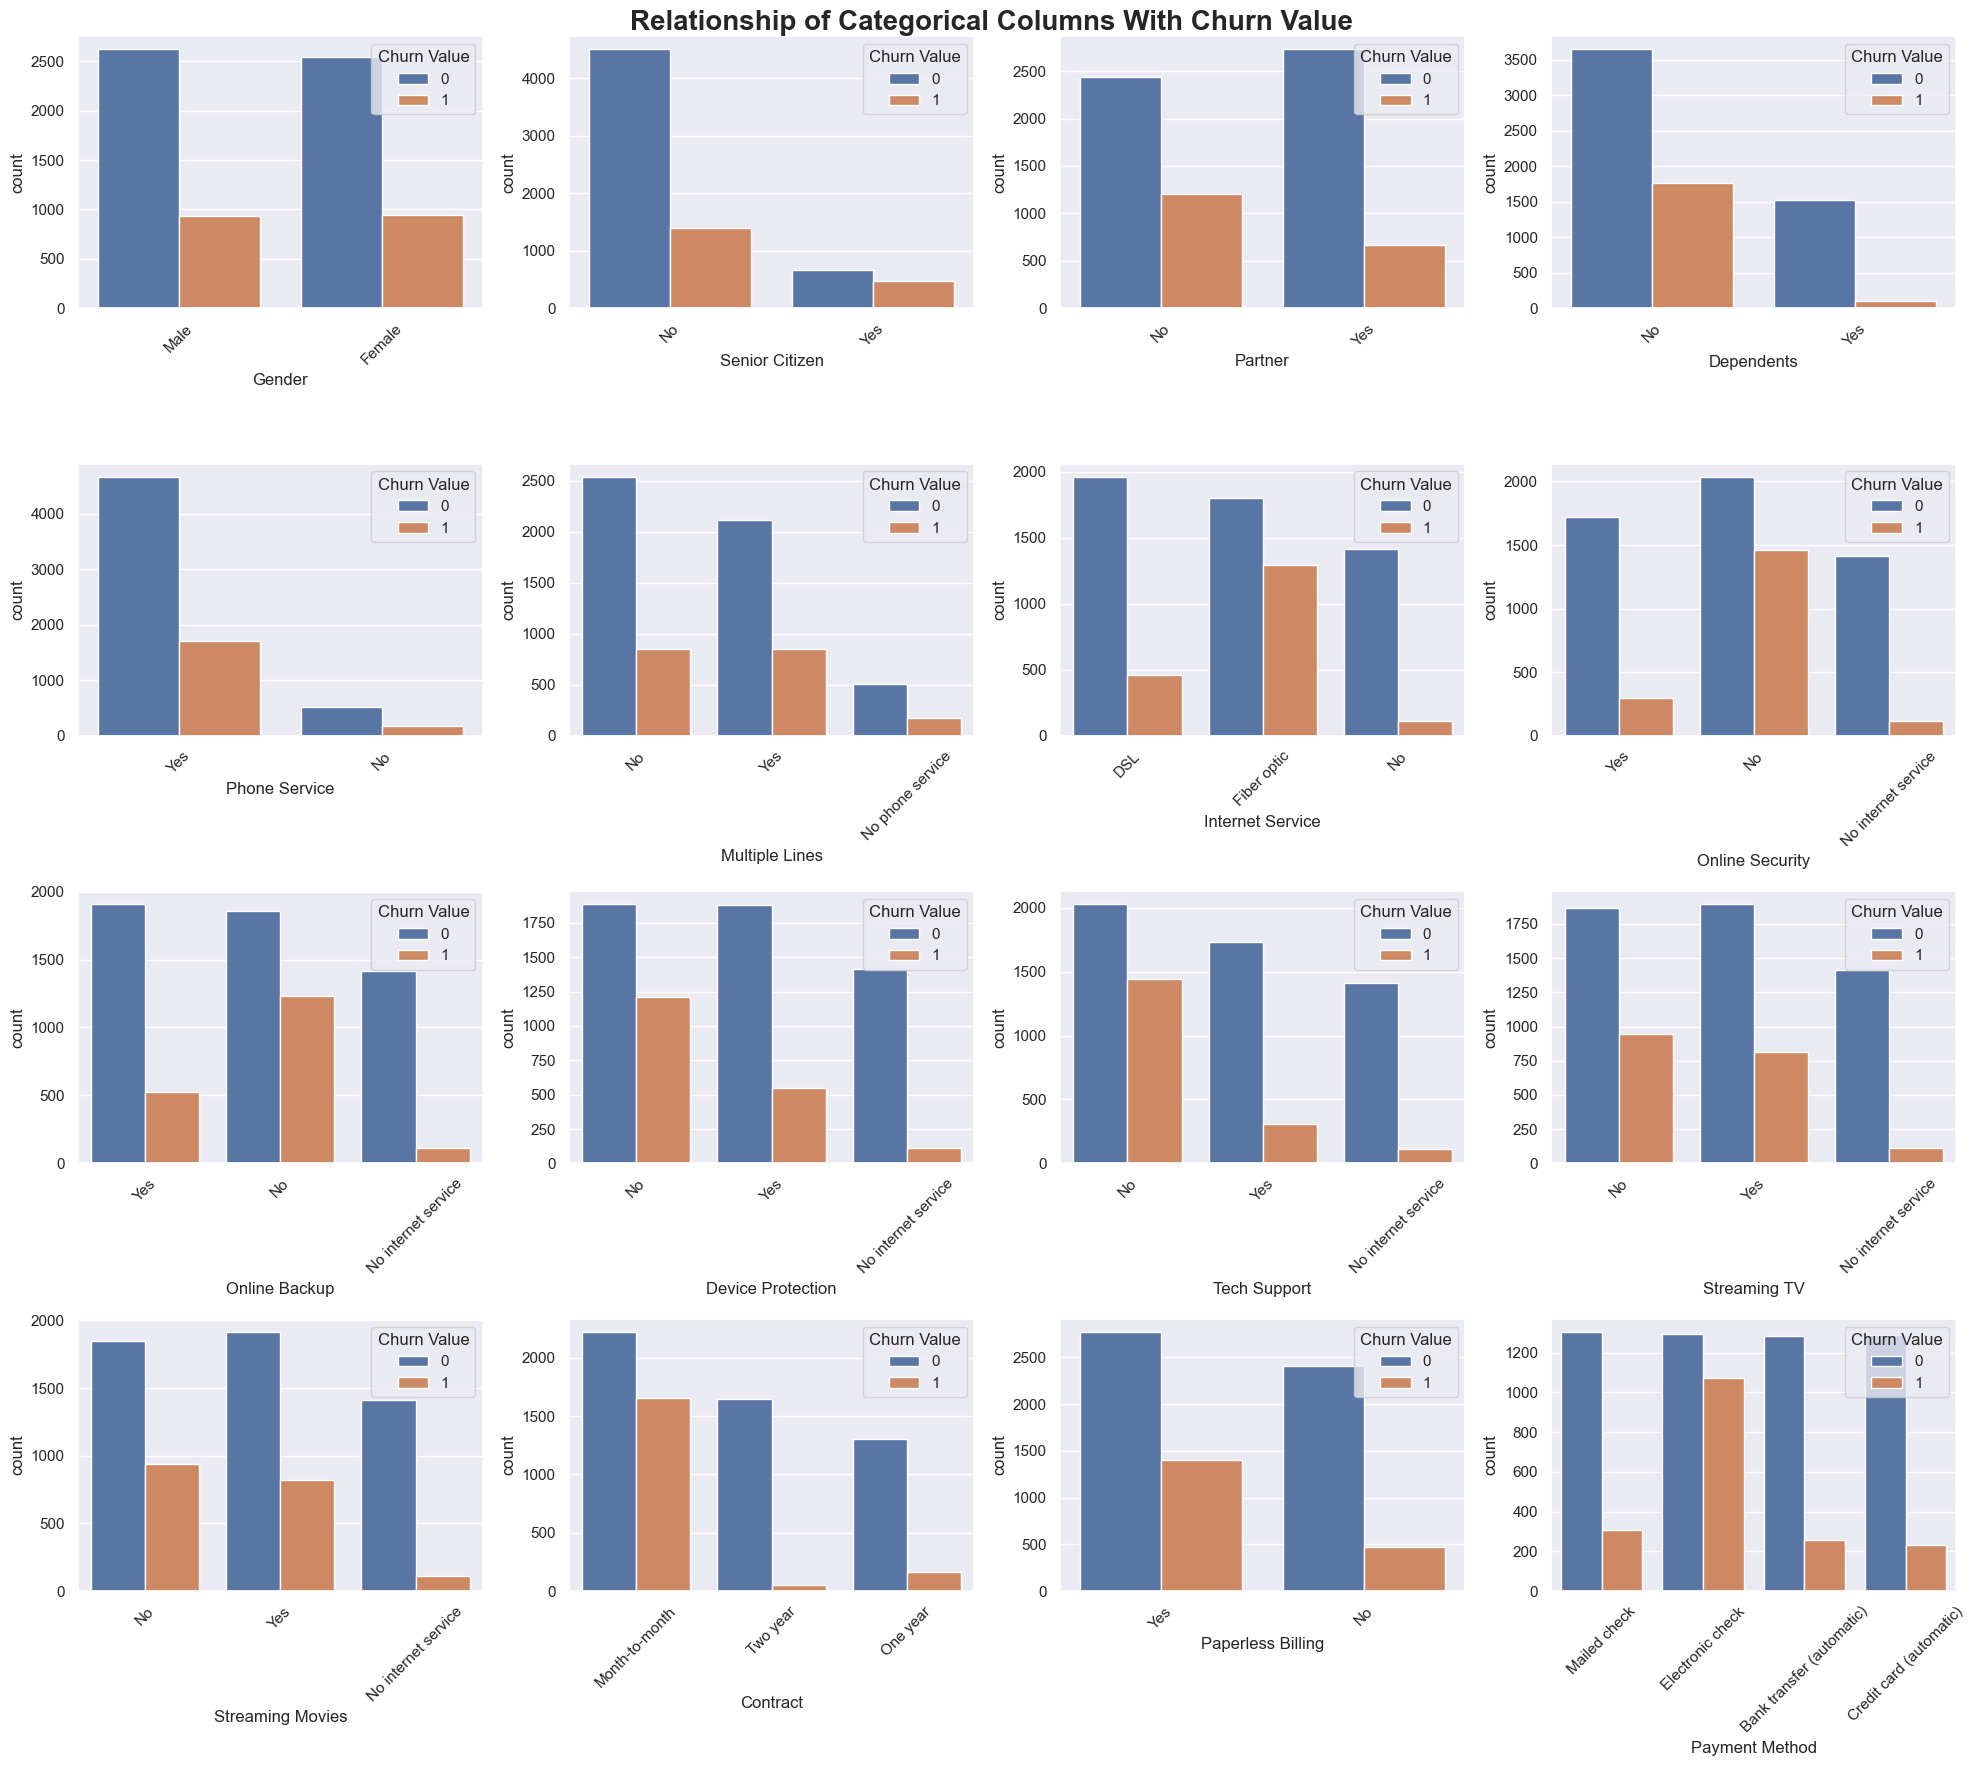

In [25]:
fig, ax = plt.subplots(4,4, figsize = (20,18))
ax = ax.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data = df, x = col, hue = 'Churn Value', ax = ax[i])
    ax[i].tick_params(axis = 'x', rotation = 45)

fig.suptitle("Relationship of Categorical Columns With Churn Value", fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

### Key Insights:
* The distribution of Churn Rate is very similar in both genders which shows gender might not be a factor for effecting Churn Value.
* Senior citizens appear to have a higher churn rate than non-senior citizens, suggesting age may be an important factor influencing customer churn.
* Customers having partner are less likely to churn.
* Dependents also affect the Churn Rate. Customers having dependents are very less likely to churn.
* All of the services features are affecting Churn Rate because as the customers are using more services they are dependent on this company and less likely to churn while the customers using less services are appear to have a higher churn rate.
* Customers with Fiber Optic internet service are leaving the company at a higher rate than other customer groups, making this feature an important factor for further analysis.
* There is a big difference in churn rate between the customer groups with different contract period. We can observe that the customers with Month-to-month contract period are having very high churn rate while two-year and one-year contract groups are having very less churn rate. This shows the customer churn rate highly depends on the period of contract.
* Similarly, in "Payment Method" feature, we can observe that the churn rate is higher among the customers using 'Electronic Check' payment method comparing to other payment methods.

### Chi Square Test

In [42]:
# Chi Square Test of all columns to check the relationship with target column
from scipy.stats import chi2_contingency
results = []
for col in cat_cols: 
    ct = pd.crosstab(df[col], df['Churn Value'])
    chi2, p, dof, expected = chi2_contingency(ct)
    results.append([col, p, 'Yes' if p < 0.05 else 'No'])

chi_table = pd.DataFrame(
    results,
    columns=['Feature', 'P-value', 'Significant']
)

chi_table.sort_values('P-value')

,Feature,P-value,Significant
13,Contract,5.863038e-258,Yes
7,Online Security,2.661150e-185,Yes
10,Tech Support,1.443084e-180,Yes
6,Internet Service,9.571788e-160,Yes
15,Payment Method,3.682355e-140,Yes
8,Online Backup,2.079759e-131,Yes
9,Device Protection,5.505219e-122,Yes
3,Dependents,2.500972e-96,Yes
12,Streaming Movies,2.667757e-82,Yes
11,Streaming TV,5.528994e-82,Yes


### Key Insight:
Most customer service and subscription-related features are significantly associated with churn. Features such as Contract Type, Internet Service, Online Security, and Tech Support appear to be important factors affecting customer retention. However, Gender and Phone Service show no significant association with churn, indicating that they are unlikely to be useful predictors of customer churn.

### High Risk Segment Analysis

In [56]:
high_risk = pd.crosstab([df['Contract'], df['Internet Service']],df['Churn Value'],normalize='index') * 100

high_risk

Churn Value                              0          1
Contract       Internet Service                      
Month-to-month DSL               67.784137  32.215863
               Fiber optic       45.394737  54.605263
               No                81.106870  18.893130
One year       DSL               90.701754   9.298246
               Fiber optic       80.705009  19.294991
               No                97.527473   2.472527
Two year       DSL               98.089172   1.910828
               Fiber optic       92.773893   7.226107
               No                99.216301   0.783699

### Key Insights:
* Customers with Month-to-month contract and Fiber optic connection has the highest churn rate (54.6%) among all the other combinations, making it the highest at-risk customer segment.
* Fiber Optic users are consistently showing the highset churn rate than other internet services.
* Churn rate decreases significantly as the contract duration increases. i.e, both contract period duration and internet service type are combiningly affecting the churn rate.
* Customers with Two year contract duration and no internet service are having the lowest churn rate (0.8%) showing the strongest retention among all groups.

In [60]:
pd.crosstab([df['Contract'], df['Online Security']],df['Churn Value'],normalize='index') * 100

Churn Value                                 0          1
Contract       Online Security                          
Month-to-month No                   48.954770  51.045230
               No internet service  81.106870  18.893130
               Yes                  70.416667  29.583333
One year       No                   82.585278  17.414722
               No internet service  97.527473   2.472527
               Yes                  89.130435  10.869565
Two year       No                   93.225806   6.774194
               No internet service  99.216301   0.783699
               Yes                  97.054886   2.945114

### Key Insights:
* Customers on Month-to-Month contracts without Online Security have the highest churn rate (51.0%), making them the most risky customer segment.
* Across all the contract durations, customers with Online Security show lower churn rates compared to those without Online Security.
* The presence of Online Security appears to improve customer retention, especially for Month-to-Month customers.
* Customers with One-Year and Two-Year contracts have substantially lower churn rates regardless of their Online Security status.

In [61]:
pd.crosstab([df['Contract'], df['Tech Support']], df['Churn Value'], normalize = 'index')*100

Churn Value                                 0          1
Contract       Tech Support                             
Month-to-month No                   49.626866  50.373134
               No internet service  81.106870  18.893130
               Yes                  69.299553  30.700447
One year       No                   85.278276  14.721724
               No internet service  97.527473   2.472527
               Yes                  86.413043  13.586957
Two year       No                   94.067797   5.932203
               No internet service  99.216301   0.783699
               Yes                  96.467722   3.532278

### Key Insights:
* In Contract and Tech Support also, we can observe the same pattern as other service features. Customers with less contract duration and No Tech Support show higher churn rate.
* Customers with Two year contract duration show least churn rate regardless of Tech Support.

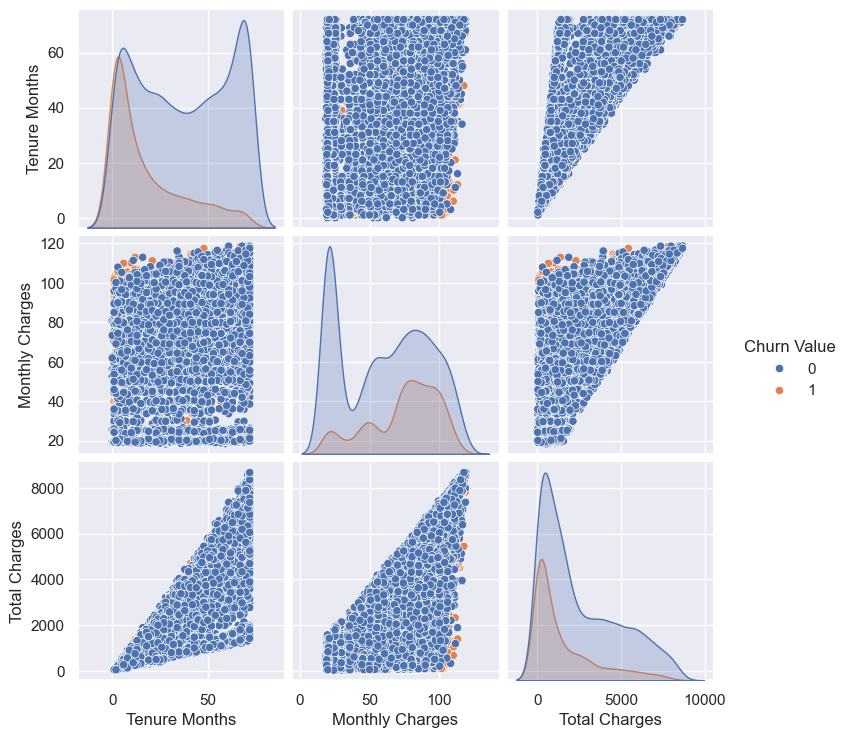

In [87]:
sns.pairplot(df[num_cols + ['Churn Value']], hue='Churn Value')

<function matplotlib.pyplot.show(close=None, block=None)>

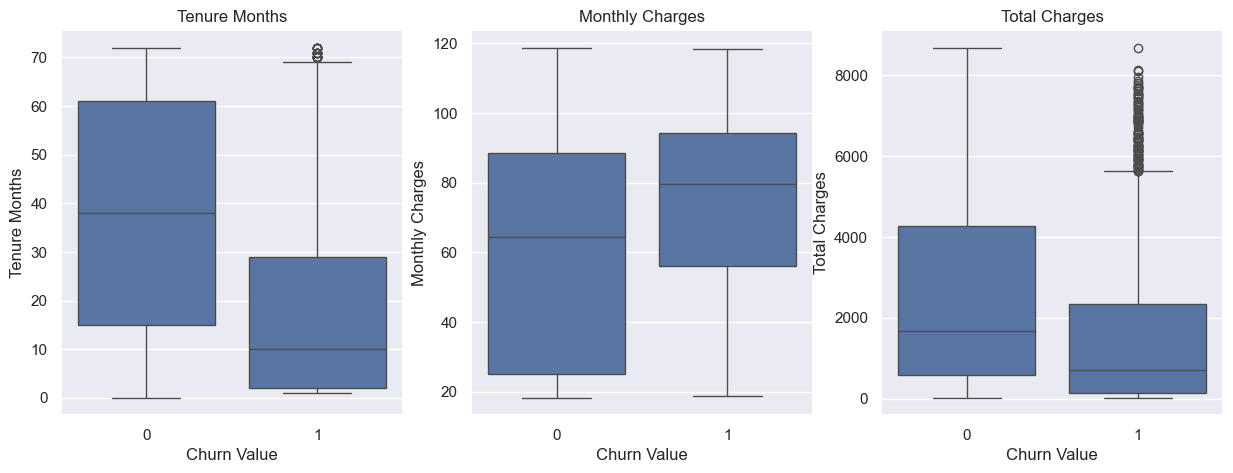

In [73]:
fig, ax = plt.subplots(1,3, figsize = (15,5))
for col in num_cols:
    sns.boxplot(x = 'Churn Value', y = col, data = df, ax = ax[num_cols.index(col)])
    ax[num_cols.index(col)].set_title(col)
plt.show

Text(0.5, 1.0, 'Numerical Columns Correlation Heatmap')

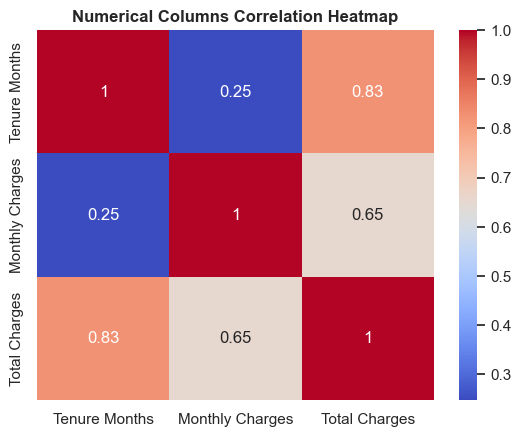

In [ ]:
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Numerical Columns Correlation Heatmap", fontweight = 'bold')

### Key Insights:
* Total Charges is strongly related to Tenure Months (0.83). Customers who remain with the company for more months generally have higher total charges.